# Optimization

- optymalizacja cech (macierz korelacji - obowiązkowo, select k-best, optuna etc - dowolne metody ustalmy że miminum dwie metody wybrane)
- optymalizacja hiperparametrów (3.0-4.0 -grid search, 4.0-4.5 - optuna lub podobny, 5.0 - genetyka). Każda wyższa ocena powinna zawierać zagadnienia na ocenę niżej, tj dla 4.5 należy wykonać optunę i gridsearch oraz porównać wyniki.
- dokładne podsumowanie wyników.
- Prosze optymalizować tylko najlepszy z modeli.
- W optymalizacji proszę używać CV
- Proszę wybrać minimum jeden model auto-ml
- Wszystkie wyniki proszę dokładnie porównać, przed po optymalizacji, jakie są uzyski, która metoda jest najlepsza

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

np.random.seed(42)

### Load datasets

In [6]:
restore_folder = "scaled_data"
restored_datasets = {}

for filename in os.listdir(restore_folder):
    if filename.endswith(".csv"):
        key = filename.replace(".csv", "")
        df = pd.read_csv(f"{restore_folder}/{filename}")
        restored_datasets[key] = df

print("\nRestored datasets keys:\n")
for k, _ in restored_datasets.items():
    print( k)

scaled_datasets = restored_datasets


Restored datasets keys:

base
constant_minmax
constant_zscore
interpolated_minmax
interpolated_zscore
knn_minmax
knn_zscore
pycaret_mean_minmax
pycaret_mean_zscore


from previous notebook: best model is `CatBoost`

and highest accuracy and F1 apart from `base` was on: `constant_zscore` dataset

In [7]:
def stratified_train_val_test_split(X, y, test_size=0.2, val_size=0.1, random_state=42):
    if hasattr(X, 'values'):
        X = X.values
    if hasattr(y, 'values'):
        y = y.values

    classes = np.unique(y)
    train_indices = []
    val_indices = []
    test_indices = []

    rng = np.random.RandomState(random_state)

    for cls in classes:
        cls_idx = np.where(y == cls)[0].tolist()
        rng.shuffle(cls_idx)
        n = len(cls_idx)
        n_test = int(round(n * test_size))
        n_val = int(round(n * val_size))

        test_idx = cls_idx[:n_test]
        val_idx = cls_idx[n_test:n_test + n_val]
        train_idx = cls_idx[n_test + n_val:]

        train_indices.extend(train_idx)
        val_indices.extend(val_idx)
        test_indices.extend(test_idx)

    # Convert to numpy arrays for indexing
    train_indices = np.array(train_indices, dtype=int)
    val_indices = np.array(val_indices, dtype=int)
    test_indices = np.array(test_indices, dtype=int)

    X_train = X[train_indices]
    X_val = X[val_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_val = y[val_indices]
    y_test = y[test_indices]

    return X_train, X_val, X_test, y_train, y_val, y_test

df = scaled_datasets['pycaret_mean_zscore']
target = 'Diagnosis'
X = df.drop(columns=[target])
y = df[target].astype(int)

X_train, X_val, X_test, y_train, y_val, y_test = stratified_train_val_test_split(
    X, y, test_size=0.2, val_size=0.1, random_state=42
)

In [8]:
# Convert to DataFrame for feature selection
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_val_df = pd.DataFrame(X_val, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

## Feature selection

### Method 1: Correlation Matrix 

**How it works:**
- Calculates the absolute correlation between all pairs of features
- Identifies highly correlated features (above threshold of 0.95)
- Removes one feature from each highly correlated pair to reduce multicollinearity
- Rationale: Highly correlated features are redundant and don't add new information to the model

In [17]:

correlation_matrix = X_train_df.corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
drop_features_corr = [col for col in upper_triangle.columns if any(abs(upper_triangle[col]) > 0.95)]
features_after_corr = [col for col in X_train_df.columns if col not in drop_features_corr]

print(f"all features: {len(X_train_df.columns)}")
print(f"Correlation method: Removed {len(drop_features_corr)} features with high correlation")
print("Remaining features:")
[print(" ", f) for f in features_after_corr]

X_train_corr = X_train_df[features_after_corr]
X_val_corr = X_val_df[features_after_corr]
X_test_corr = X_test_df[features_after_corr]

all features: 35
Correlation method: Removed 0 features with high correlation
Remaining features:
  Age
  Gender
  EducationLevel
  BMI
  Smoking
  AlcoholConsumption
  PhysicalActivity
  DietQuality
  SleepQuality
  FamilyHistoryAlzheimers
  CardiovascularDisease
  Diabetes
  Depression
  HeadInjury
  Hypertension
  SystolicBP
  DiastolicBP
  CholesterolTotal
  CholesterolLDL
  CholesterolHDL
  CholesterolTriglycerides
  MMSE
  FunctionalAssessment
  MemoryComplaints
  BehavioralProblems
  ADL
  Confusion
  Disorientation
  PersonalityChanges
  DifficultyCompletingTasks
  Forgetfulness
  Ethnicity_African American
  Ethnicity_Asian
  Ethnicity_Caucasian
  Ethnicity_Other


In [18]:
# Print correlations sorted by max correlation value
print("Features sorted by maximum correlation with others:")
corr_dict = {}
for col in upper_triangle.columns:
    max_corr = upper_triangle[col].max()
    corr_dict[col] = max_corr

for col, corr_val in sorted(corr_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"{col}: {corr_val:.4f}")

Features sorted by maximum correlation with others:
Age: nan
Ethnicity_Caucasian: 0.5634
Ethnicity_Other: 0.3540
Ethnicity_Asian: 0.1588
BehavioralProblems: 0.0745
Confusion: 0.0737
CholesterolTriglycerides: 0.0702
FunctionalAssessment: 0.0687
Forgetfulness: 0.0672
Diabetes: 0.0664
CholesterolHDL: 0.0660
DiastolicBP: 0.0653
FamilyHistoryAlzheimers: 0.0640
DifficultyCompletingTasks: 0.0633
CholesterolLDL: 0.0631
SleepQuality: 0.0621
PhysicalActivity: 0.0577
ADL: 0.0574
Disorientation: 0.0563
EducationLevel: 0.0518
CholesterolTotal: 0.0509
CardiovascularDisease: 0.0496
MMSE: 0.0483
Ethnicity_African American: 0.0473
Hypertension: 0.0443
HeadInjury: 0.0436
DietQuality: 0.0430
Depression: 0.0427
SystolicBP: 0.0421
MemoryComplaints: 0.0419
PersonalityChanges: 0.0402
AlcoholConsumption: 0.0348
Smoking: 0.0344
BMI: 0.0278
Gender: 0.0025


The features are very little correlated to each other so we don't remove any based on that approach. 

### Method 2: SelectKBest with f_classif

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

k_best = SelectKBest(score_func=f_classif, k=min(15, X_train_df.shape[1]))
k_best.fit(X_train_df, y_train)
features_kbest = X_train_df.columns[k_best.get_support()].tolist()

print(f"SelectKBest method: Selected top {len(features_kbest)} features")

for f in features_kbest:
    print(" ", f)

X_train_kbest = X_train_df[features_kbest]
X_val_kbest = X_val_df[features_kbest]
X_test_kbest = X_test_df[features_kbest]

SelectKBest method: Selected top 15 features
  EducationLevel
  SleepQuality
  HeadInjury
  Hypertension
  CholesterolLDL
  CholesterolHDL
  CholesterolTriglycerides
  MMSE
  FunctionalAssessment
  MemoryComplaints
  BehavioralProblems
  ADL
  Confusion
  Ethnicity_Asian
  Ethnicity_Other


### Method 3: RFE (Recursive Feature Elimination)

In [19]:
from sklearn.feature_selection import RFE
from catboost import CatBoostClassifier

rfe = RFE(estimator=CatBoostClassifier(verbose=0, random_state=42), n_features_to_select=15, step=1)
rfe.fit(X_train_df, y_train)
features_rfe = X_train_df.columns[rfe.get_support()].tolist()

print(f"RFE method: Selected top {len(features_rfe)} features")

for f in features_rfe:
    print(" ", f)

X_train_rfe = X_train_df[features_rfe]
X_val_rfe = X_val_df[features_rfe]
X_test_rfe = X_test_df[features_rfe]

RFE method: Selected top 15 features
  Age
  BMI
  AlcoholConsumption
  PhysicalActivity
  SleepQuality
  SystolicBP
  CholesterolTotal
  CholesterolLDL
  CholesterolHDL
  CholesterolTriglycerides
  MMSE
  FunctionalAssessment
  MemoryComplaints
  BehavioralProblems
  ADL


### Comparison of feature selection methods

In [20]:
print("Feature Selection Methods Comparison:")
print(f"Original features: {X_train_df.shape[1]}")
print(f"Correlation method: {len(features_after_corr)} features - none removed")
print(f"SelectKBest method: {len(features_kbest)} features")
print(f"RFE method: {len(features_rfe)} features")
common = set(features_after_corr) & set(features_kbest) & set(features_rfe)
print(f"\n{len(common)} Common features between all methods: \n")
for f in common: print(" ", f)

Feature Selection Methods Comparison:
Original features: 35
Correlation method: 35 features - none removed
SelectKBest method: 15 features
RFE method: 15 features

9 Common features between all methods: 

  BehavioralProblems
  CholesterolLDL
  ADL
  SleepQuality
  CholesterolHDL
  MemoryComplaints
  MMSE
  FunctionalAssessment
  CholesterolTriglycerides


## Quick Model Training with Selected Features

Train CatBoost with features selected by each method and compare performance.

In [21]:
from sklearn.metrics import accuracy_score, f1_score

# Train on SelectKBest features
print("=" * 50)
print("SelectKBest Features Results")
print("=" * 50)
model_kbest = CatBoostClassifier(verbose=0, random_state=42)
model_kbest.fit(X_train_kbest, y_train)

y_pred_kbest = model_kbest.predict(X_test_kbest)
acc_kbest = accuracy_score(y_test, y_pred_kbest)
f1_kbest = f1_score(y_test, y_pred_kbest, average='weighted')

print(f"Accuracy: {acc_kbest:.4f}")
print(f"F1 Score: {f1_kbest:.4f}\n")


SelectKBest Features Results
Accuracy: 0.8930
F1 Score: 0.8915



In [22]:
# Train on RFE features
print("=" * 50)
print("RFE Features Results")
print("=" * 50)
model_rfe = CatBoostClassifier(verbose=0, random_state=42)
model_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = model_rfe.predict(X_test_rfe)
acc_rfe = accuracy_score(y_test, y_pred_rfe)
f1_rfe = f1_score(y_test, y_pred_rfe, average='weighted')

print(f"Accuracy: {acc_rfe:.4f}")
print(f"F1 Score: {f1_rfe:.4f}\n")

RFE Features Results
Accuracy: 0.8907
F1 Score: 0.8891



In [23]:
# Train on all features (baseline)
print("=" * 50)
print("All Features (Baseline)")
print("=" * 50)
model_all = CatBoostClassifier(verbose=0, random_state=42)
model_all.fit(X_train_df, y_train)

y_pred_all = model_all.predict(X_test_df)
acc_all = accuracy_score(y_test, y_pred_all)
f1_all = f1_score(y_test, y_pred_all, average='weighted')

print(f"Accuracy: {acc_all:.4f}")
print(f"F1 Score: {f1_all:.4f}\n")


All Features (Baseline)
Accuracy: 0.8837
F1 Score: 0.8819



### Summary comparison

In [24]:
print("=" * 50)
print("SUMMARY")
print("=" * 50)
results = pd.DataFrame({
    'Method': ['All Features', 'SelectKBest', 'RFE'],
    'Num Features': [X_train_df.shape[1], len(features_kbest), len(features_rfe)],
    'Accuracy': [acc_all, acc_kbest, acc_rfe],
    'F1 Score': [f1_all, f1_kbest, f1_rfe]
})
print(results.to_string(index=False))

SUMMARY
      Method  Num Features  Accuracy  F1 Score
All Features            35  0.883721  0.881885
 SelectKBest            15  0.893023  0.891548
         RFE            15  0.890698  0.889082


## Feature Importance from CatBoost

In [25]:
# Feature importance from model trained on all features
feature_importance = model_all.get_feature_importance()
feature_importance_df = pd.DataFrame({
    'Feature': X_train_df.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance (All Features Model):")
print(feature_importance_df.to_string(index=False))

Feature Importance (All Features Model):
                   Feature  Importance
      FunctionalAssessment   18.447186
                       ADL   15.831981
                      MMSE   14.186968
          MemoryComplaints   11.513354
        BehavioralProblems    7.490364
            CholesterolLDL    2.267580
            CholesterolHDL    2.165913
  CholesterolTriglycerides    2.101451
                       Age    2.011075
                       BMI    1.902201
              SleepQuality    1.844707
        AlcoholConsumption    1.825546
                SystolicBP    1.759381
          PhysicalActivity    1.658891
          CholesterolTotal    1.349348
               DietQuality    1.227683
               DiastolicBP    1.077867
                    Gender    0.948203
                 Confusion    0.858666
            EducationLevel    0.840801
       Ethnicity_Caucasian    0.825546
                   Smoking    0.775337
                Depression    0.703093
        PersonalityChan

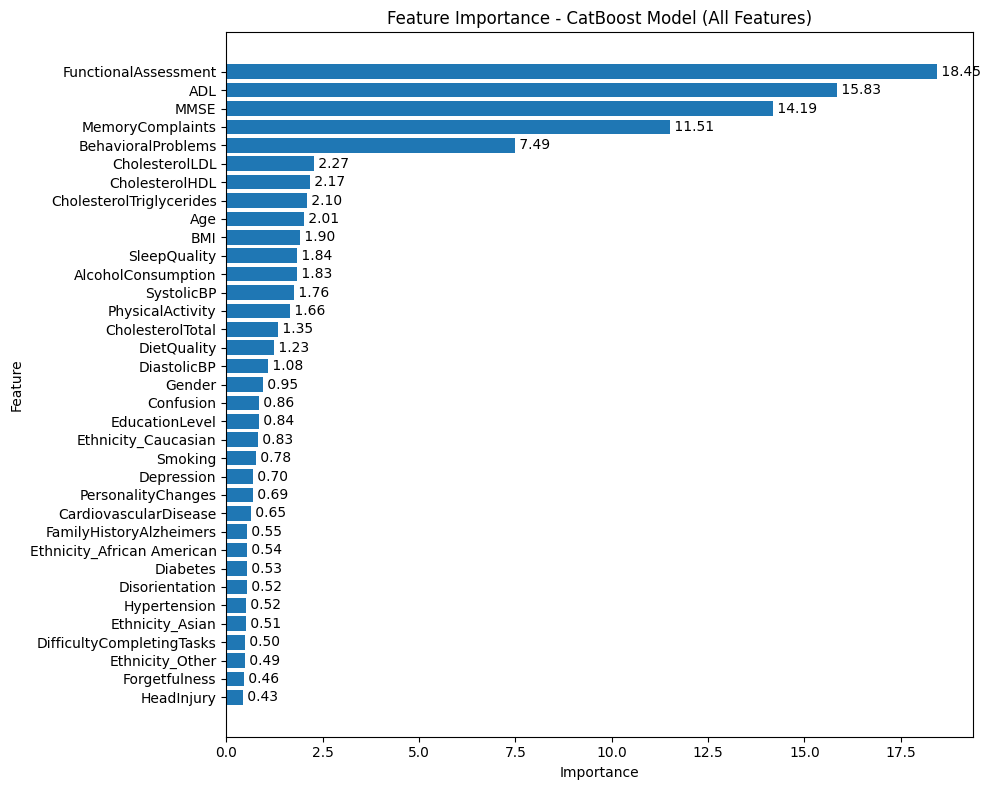

In [26]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])

# Add value labels on bars
for i, (feature, importance) in enumerate(zip(feature_importance_df['Feature'], feature_importance_df['Importance'])):
    ax.text(importance, i, f' {importance:.2f}', va='center')

ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance - CatBoost Model (All Features)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Hyperparameter Optimization

In [27]:
all_params = model_all.get_all_params()
all_params

{'nan_mode': 'Min',
 'eval_metric': 'Logloss',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': False,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'class_names': [0, 1],
 'random_seed': 42,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'l

In [28]:
### Grid Search for CatBoost - All Features
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score

# Define hyperparameter grid for CatBoost
param_grid = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.0122, 0.05],
    'iterations': [5, 10, 20],
    'l2_leaf_reg': [1, 3, 5]
}

print("=" * 70)
print("GRID SEARCH - ALL FEATURES")
print("=" * 70)
print(f"Parameter grid: {param_grid}\n")

# Create base CatBoost classifier
base_model = CatBoostClassifier(verbose=0, random_state=42)

# Grid search with cross-validation
grid_search_all = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
)

print("Training GridSearchCV on all features...")
grid_search_all.fit(X_train_df, y_train)

print(f"\nBest parameters: {grid_search_all.best_params_}")
print(f"Best CV F1 Score: {grid_search_all.best_score_:.4f}")

GRID SEARCH - ALL FEATURES
Parameter grid: {'depth': [4, 6, 8, 10], 'learning_rate': [0.01, 0.0122, 0.05], 'iterations': [5, 10, 20], 'l2_leaf_reg': [1, 3, 5]}

Training GridSearchCV on all features...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'depth': 8, 'iterations': 10, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Best CV F1 Score: 0.9039


In [29]:
# Evaluate best model on test set
best_model_all = grid_search_all.best_estimator_
y_pred_gs_all = best_model_all.predict(X_test_df)

acc_gs_all = accuracy_score(y_test, y_pred_gs_all)
f1_gs_all = f1_score(y_test, y_pred_gs_all, average='weighted')
precision_gs_all = precision_score(y_test, y_pred_gs_all, average='weighted')
recall_gs_all = recall_score(y_test, y_pred_gs_all, average='weighted')

print(f"\nTest Set Results (All Features - GridSearch):")
print(f"Accuracy: {acc_gs_all:.4f}")
print(f"F1 Score: {f1_gs_all:.4f}")
print(f"Precision: {precision_gs_all:.4f}")
print(f"Recall: {recall_gs_all:.4f}")

print("\n" + "=" * 70)
print("COMPARISON: Before vs After GridSearch (All Features)")
print("=" * 70)
comparison_all = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Before': [acc_all, f1_all, 
               precision_score(y_test, y_pred_all, average='weighted'),
               recall_score(y_test, y_pred_all, average='weighted')],
    'After GridSearch': [acc_gs_all, f1_gs_all, precision_gs_all, recall_gs_all]
})
print(comparison_all.to_string(index=False))


Test Set Results (All Features - GridSearch):
Accuracy: 0.8884
F1 Score: 0.8868
Precision: 0.8880
Recall: 0.8884

COMPARISON: Before vs After GridSearch (All Features)
   Metric   Before  After GridSearch
 Accuracy 0.883721          0.888372
 F1 Score 0.881885          0.886833
Precision 0.883531          0.888045
   Recall 0.883721          0.888372


In [30]:
### Grid Search for CatBoost - SelectKBest Features
print("\n" + "=" * 70)
print("GRID SEARCH - SELECTKBEST FEATURES")
print("=" * 70)
print(f"Parameter grid: {param_grid}\n")

# Grid search on SelectKBest features
grid_search_kbest = GridSearchCV(
    estimator=CatBoostClassifier(verbose=0, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=3
)

print("Training GridSearchCV on SelectKBest features...")
grid_search_kbest.fit(X_train_kbest, y_train)

print(f"\nBest parameters: {grid_search_kbest.best_params_}")
print(f"Best CV F1 Score: {grid_search_kbest.best_score_:.4f}")


GRID SEARCH - SELECTKBEST FEATURES
Parameter grid: {'depth': [4, 6, 8, 10], 'learning_rate': [0.01, 0.0122, 0.05], 'iterations': [5, 10, 20], 'l2_leaf_reg': [1, 3, 5]}

Training GridSearchCV on SelectKBest features...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'depth': 8, 'iterations': 10, 'l2_leaf_reg': 1, 'learning_rate': 0.05}
Best CV F1 Score: 0.9040


In [31]:
# Evaluate best model on test set
best_model_kbest = grid_search_kbest.best_estimator_
y_pred_gs_kbest = best_model_kbest.predict(X_test_kbest)

acc_gs_kbest = accuracy_score(y_test, y_pred_gs_kbest)
f1_gs_kbest = f1_score(y_test, y_pred_gs_kbest, average='weighted')
precision_gs_kbest = precision_score(y_test, y_pred_gs_kbest, average='weighted')
recall_gs_kbest = recall_score(y_test, y_pred_gs_kbest, average='weighted')

print(f"\nTest Set Results (SelectKBest - GridSearch):")
print(f"Accuracy: {acc_gs_kbest:.4f}")
print(f"F1 Score: {f1_gs_kbest:.4f}")
print(f"Precision: {precision_gs_kbest:.4f}")
print(f"Recall: {recall_gs_kbest:.4f}")

print("\n" + "=" * 70)
print("COMPARISON: Before vs After GridSearch (SelectKBest)")
print("=" * 70)
comparison_kbest = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Before': [acc_kbest, f1_kbest,
               precision_score(y_test, y_pred_kbest, average='weighted'),
               recall_score(y_test, y_pred_kbest, average='weighted')],
    'After GridSearch': [acc_gs_kbest, f1_gs_kbest, precision_gs_kbest, recall_gs_kbest]
})
print(comparison_kbest.to_string(index=False))


Test Set Results (SelectKBest - GridSearch):
Accuracy: 0.8953
F1 Score: 0.8944
Precision: 0.8947
Recall: 0.8953

COMPARISON: Before vs After GridSearch (SelectKBest)
   Metric   Before  After GridSearch
 Accuracy 0.893023          0.895349
 F1 Score 0.891548          0.894400
Precision 0.892843          0.894743
   Recall 0.893023          0.895349


## Hyperparameter Optimization using Optuna

In [32]:
import optuna
from optuna.integration import CatBoostPruningCallback

optuna.__version__

'4.6.0'

### Optuna Optimization - All Features

```py
param_grid = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.0122, 0.05],
    'iterations': [5, 10, 20],
    'l2_leaf_reg': [1, 3, 5]
}


In [33]:
# Define objective function for All Features
def objective_all_features(trial: optuna.Trial) -> float:
    param = {
        "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 1, 16),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
        "iterations": trial.suggest_int("iterations", 100, 600),
        "used_ram_limit": "3gb",
        "eval_metric": "F1",
        "verbose": 0
    }

    # Add conditional parameters based on bootstrap_type
    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1, log=True)

    # Train CatBoost model
    model = CatBoostClassifier(**param)
    
    pruning_callback = CatBoostPruningCallback(trial, "F1")
    model.fit(
        X_train_df,
        y_train,
        eval_set=[(X_val_df, y_val)],
        verbose=0,
        early_stopping_rounds=50,
        callbacks=[pruning_callback],
    )

    # Check if trial was pruned
    pruning_callback.check_pruned()

    # Evaluate on validation set
    y_pred = model.predict(X_val_df)
    f1_score_val = f1_score(y_val, y_pred, average='weighted')

    return f1_score_val

In [34]:
import warnings

# # Suppress all warnings
# warnings.filterwarnings('ignore')

# Specifically suppress Optuna's ExperimentalWarning
warnings.filterwarnings('ignore', category=optuna.exceptions.ExperimentalWarning)
print("Optuna version:", optuna.__version__)

Optuna version: 4.6.0


In [35]:
print("=" * 70)
print("OPTUNA OPTIMIZATION - ALL FEATURES")
print("=" * 70)

# Create study with MedianPruner
study_all = optuna.create_study(
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting optimization\n")
study_all.optimize(objective_all_features, n_trials=50, show_progress_bar=True)

[I 2025-12-29 16:01:20,823] A new study created in memory with name: no-name-e1e79f76-fe5f-4d4a-9eac-d779b0284866


OPTUNA OPTIMIZATION - ALL FEATURES
Starting optimization



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-29 16:01:21,485] Trial 0 finished with value: 0.6924678436445811 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.05395030966670229, 'depth': 10, 'learning_rate': 0.0020513382630874496, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'l2_leaf_reg': 1, 'iterations': 585, 'bagging_temperature': 8.324426408004218}. Best is trial 0 with value: 0.6924678436445811.
[I 2025-12-29 16:01:21,790] Trial 1 finished with value: 0.5077125213506766 and parameters: {'objective': 'Logloss', 'colsample_bylevel': 0.015254729458052608, 'depth': 5, 'learning_rate': 0.01120760621186057, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'l2_leaf_reg': 4, 'iterations': 328, 'bagging_temperature': 7.851759613930136}. Best is trial 0 with value: 0.6924678436445811.
[I 2025-12-29 16:01:22,097] Trial 2 finished with value: 0.5077125213506766 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.03912141628549695, 'depth': 1, 'learning_rate': 0.016409

In [36]:
print("\n" + "=" * 70)
print("OPTUNA RESULTS - ALL FEATURES")
print("=" * 70)
print(f"Number of finished trials: {len(study_all.trials)}")
print(f"Best trial (Validation F1): {study_all.best_value:.4f}")

print("Best hyperparameters:")
study_all.best_trial.params


OPTUNA RESULTS - ALL FEATURES
Number of finished trials: 50
Best trial (Validation F1): 0.9386
Best hyperparameters:


{'objective': 'CrossEntropy',
 'colsample_bylevel': 0.07849235338159358,
 'depth': 10,
 'learning_rate': 0.06978281265126034,
 'boosting_type': 'Plain',
 'bootstrap_type': 'MVS',
 'l2_leaf_reg': 3,
 'iterations': 515}

In [37]:
# Train best model on test set - All Features

best_params_all = study_all.best_trial.params
model_optuna_all = CatBoostClassifier(**best_params_all, verbose=1)
model_optuna_all.fit(X_train_df, y_train)

y_pred_optuna_all = model_optuna_all.predict(X_test_df)
acc_optuna_all = accuracy_score(y_test, y_pred_optuna_all)
f1_optuna_all = f1_score(y_test, y_pred_optuna_all, average='weighted')
precision_optuna_all = precision_score(y_test, y_pred_optuna_all, average='weighted')
recall_optuna_all = recall_score(y_test, y_pred_optuna_all, average='weighted')

print("\nTest Set Results (All Features - Optuna Best Model):")
print(f"Accuracy: {acc_optuna_all:.4f}")
print(f"F1 Score: {f1_optuna_all:.4f}")
print(f"Precision: {precision_optuna_all:.4f}")
print(f"Recall: {recall_optuna_all:.4f}")

# Comparison: Before, GridSearch, and Optuna
print("\n" + "=" * 70)
print("COMPARISON: All Optimization Methods (All Features)")
print("=" * 70)
comparison_all_methods = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Baseline': [acc_all, f1_all, 
                 precision_score(y_test, y_pred_all, average='weighted'),
                 recall_score(y_test, y_pred_all, average='weighted')],
    'GridSearch': [acc_gs_all, f1_gs_all, precision_gs_all, recall_gs_all],
    'Optuna': [acc_optuna_all, f1_optuna_all, precision_optuna_all, recall_optuna_all]
})
print(comparison_all_methods.to_string(index=False))

0:	learn: 0.6449680	total: 12.5ms	remaining: 6.4s
1:	learn: 0.6310900	total: 13.5ms	remaining: 3.47s
2:	learn: 0.5953122	total: 23ms	remaining: 3.92s
3:	learn: 0.5727064	total: 26.5ms	remaining: 3.38s
4:	learn: 0.5543174	total: 28.5ms	remaining: 2.9s
5:	learn: 0.5518851	total: 29.4ms	remaining: 2.5s
6:	learn: 0.5432888	total: 30.4ms	remaining: 2.21s
7:	learn: 0.5300974	total: 32.1ms	remaining: 2.04s
8:	learn: 0.5154865	total: 43.3ms	remaining: 2.43s
9:	learn: 0.4940418	total: 52.3ms	remaining: 2.64s
10:	learn: 0.4743925	total: 61.8ms	remaining: 2.83s
11:	learn: 0.4596685	total: 70.2ms	remaining: 2.94s
12:	learn: 0.4546002	total: 71.3ms	remaining: 2.75s
13:	learn: 0.4324621	total: 84ms	remaining: 3s
14:	learn: 0.4207857	total: 94ms	remaining: 3.13s
15:	learn: 0.4023791	total: 102ms	remaining: 3.17s
16:	learn: 0.3988678	total: 104ms	remaining: 3.04s
17:	learn: 0.3888422	total: 114ms	remaining: 3.15s
18:	learn: 0.3884576	total: 116ms	remaining: 3.02s
19:	learn: 0.3775587	total: 126ms	rema

In [38]:
# Compare Validation F1 (from Optuna) vs Test F1
print("\n" + "=" * 70)
print("VALIDATION vs TEST F1 SCORE (All Features - Optuna)")
print("=" * 70)
print(f"Best Validation F1 (from Optuna trials): {study_all.best_value:.4f}")
print(f"Test F1 (on held-out test set):          {f1_optuna_all:.4f}")
print(f"Difference:                              {study_all.best_value - f1_optuna_all:.4f}")


VALIDATION vs TEST F1 SCORE (All Features - Optuna)
Best Validation F1 (from Optuna trials): 0.9386
Test F1 (on held-out test set):          0.8666
Difference:                              0.0720


Validation F1 is higher because hyperparameters were tuned to maximize it

Test F1 is lower because the test set is completely unseen during optimization

### Optuna Optimization - SelectKBest Features

In [39]:
# Define objective function for SelectKBest
def objective_selectkbest(trial: optuna.Trial) -> float:
    param = {
        "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 1, 16),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
        "iterations": trial.suggest_int("iterations", 100, 600),
        "used_ram_limit": "3gb",
        "eval_metric": "F1",
        "verbose": 0
    }

    # Add conditional parameters based on bootstrap_type
    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1, log=True)

    # Train CatBoost model on SelectKBest features
    model = CatBoostClassifier(**param)
    
    pruning_callback = CatBoostPruningCallback(trial, "F1")
    model.fit(
        X_train_kbest,
        y_train,
        eval_set=[(X_val_kbest, y_val)],
        verbose=0,
        early_stopping_rounds=50,
        callbacks=[pruning_callback],
    )

    # Check if trial was pruned
    pruning_callback.check_pruned()

    # Evaluate on validation set
    y_pred = model.predict(X_val_kbest)
    f1_score_val = f1_score(y_val, y_pred, average='weighted')

    return f1_score_val

In [40]:
print("\n" + "=" * 70)
print("OPTUNA OPTIMIZATION - SELECTKBEST FEATURES")
print("=" * 70)

# Create study with MedianPruner
study_kbest = optuna.create_study(
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting optimization... (this may take a while)\n")
study_kbest.optimize(objective_selectkbest, n_trials=50, show_progress_bar=True)


[I 2025-12-29 16:02:05,858] A new study created in memory with name: no-name-1085a6ed-9531-4e90-b84c-c458d43e48b6



OPTUNA OPTIMIZATION - SELECTKBEST FEATURES
Starting optimization... (this may take a while)



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-29 16:02:06,217] Trial 0 finished with value: 0.6036175710594315 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.05395030966670229, 'depth': 10, 'learning_rate': 0.0020513382630874496, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'l2_leaf_reg': 1, 'iterations': 585, 'bagging_temperature': 8.324426408004218}. Best is trial 0 with value: 0.6036175710594315.
[I 2025-12-29 16:02:06,562] Trial 1 finished with value: 0.5919592643258853 and parameters: {'objective': 'Logloss', 'colsample_bylevel': 0.015254729458052608, 'depth': 5, 'learning_rate': 0.01120760621186057, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'l2_leaf_reg': 4, 'iterations': 328, 'bagging_temperature': 7.851759613930136}. Best is trial 0 with value: 0.6036175710594315.
[I 2025-12-29 16:02:06,701] Trial 2 finished with value: 0.5077125213506766 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.03912141628549695, 'depth': 1, 'learning_rate': 0.016409

In [41]:

print("\n" + "=" * 70)
print("OPTUNA RESULTS - SELECTKBEST FEATURES")
print("=" * 70)
print(f"Number of finished trials: {len(study_kbest.trials)}")
print(f"Best trial (Validation F1): {study_kbest.best_value:.4f}")
print("\nBest parameters:")
study_kbest.best_trial.params


OPTUNA RESULTS - SELECTKBEST FEATURES
Number of finished trials: 50
Best trial (Validation F1): 0.9434

Best parameters:


{'objective': 'CrossEntropy',
 'colsample_bylevel': 0.07849235338159358,
 'depth': 10,
 'learning_rate': 0.06978281265126034,
 'boosting_type': 'Plain',
 'bootstrap_type': 'MVS',
 'l2_leaf_reg': 3,
 'iterations': 515}

In [42]:
# Train best model on test set - SelectKBest
best_params_kbest = study_kbest.best_trial.params
model_optuna_kbest = CatBoostClassifier(**best_params_kbest, verbose=0)
model_optuna_kbest.fit(X_train_kbest, y_train)

y_pred_optuna_kbest = model_optuna_kbest.predict(X_test_kbest)
acc_optuna_kbest = accuracy_score(y_test, y_pred_optuna_kbest)
f1_optuna_kbest = f1_score(y_test, y_pred_optuna_kbest, average='weighted')
precision_optuna_kbest = precision_score(y_test, y_pred_optuna_kbest, average='weighted')
recall_optuna_kbest = recall_score(y_test, y_pred_optuna_kbest, average='weighted')

print("\nTest Set Results (SelectKBest - Optuna Best Model):")
print(f"Accuracy: {acc_optuna_kbest:.4f}")
print(f"F1 Score: {f1_optuna_kbest:.4f}")
print(f"Precision: {precision_optuna_kbest:.4f}")
print(f"Recall: {recall_optuna_kbest:.4f}")

# Comparison: Before, GridSearch, and Optuna
print("\n" + "=" * 70)
print("COMPARISON: All Optimization Methods (SelectKBest Features) 'pycaret_mean_zscore'")
print("=" * 70)
comparison_kbest_methods = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Baseline': [acc_kbest, f1_kbest,
                 precision_score(y_test, y_pred_kbest, average='weighted'),
                 recall_score(y_test, y_pred_kbest, average='weighted')],
    'GridSearch': [acc_gs_kbest, f1_gs_kbest, precision_gs_kbest, recall_gs_kbest],
    'Optuna': [acc_optuna_kbest, f1_optuna_kbest, precision_optuna_kbest, recall_optuna_kbest]
})
print(comparison_kbest_methods.to_string(index=False))


Test Set Results (SelectKBest - Optuna Best Model):
Accuracy: 0.8860
F1 Score: 0.8841
Precision: 0.8861
Recall: 0.8860

COMPARISON: All Optimization Methods (SelectKBest Features) 'pycaret_mean_zscore'
   Metric  Baseline  GridSearch   Optuna
 Accuracy  0.893023    0.895349 0.886047
 F1 Score  0.891548    0.894400 0.884131
Precision  0.892843    0.894743 0.886121
   Recall  0.893023    0.895349 0.886047


Optune is way faster than gridsearch but gives a bit worse results.

### base dataset with Optuna and SelectKBest

In [43]:
# Load base dataset
df_base = pd.read_csv('scaled_data/base.csv')
target = 'Diagnosis'
X_base = df_base.drop(columns=[target])
y_base = df_base[target].astype(int)

X_train_base, X_val_base, X_test_base, y_train_base, y_val_base, y_test_base = stratified_train_val_test_split(
    X_base, y_base, test_size=0.2, val_size=0.1, random_state=42
)

# Convert to DataFrame
X_train_base_df = pd.DataFrame(X_train_base, columns=X_base.columns)
X_val_base_df = pd.DataFrame(X_val_base, columns=X_base.columns)
X_test_base_df = pd.DataFrame(X_test_base, columns=X_base.columns)

# Apply SelectKBest to base dataset
k_best_base = SelectKBest(score_func=f_classif, k=min(15, X_train_base_df.shape[1]))
k_best_base.fit(X_train_base_df, y_train_base)
features_kbest_base = X_train_base_df.columns[k_best_base.get_support()].tolist()

X_train_base_kbest = X_train_base_df[features_kbest_base]
X_val_base_kbest = X_val_base_df[features_kbest_base]
X_test_base_kbest = X_test_base_df[features_kbest_base]

print("=" * 70)
print("BASE DATASET - SELECTKBEST FEATURES")
print("=" * 70)
print(f"Total base features: {X_train_base_df.shape[1]}")
print(f"Selected features (SelectKBest): {len(features_kbest_base)}")

# Baseline: SelectKBest with default params
print("\n" + "=" * 70)
print("BASELINE - BASE DATASET (SelectKBest + Default Params)")
print("=" * 70)
model_base_kbest = CatBoostClassifier(verbose=0, random_state=42)
model_base_kbest.fit(X_train_base_kbest, y_train_base)

y_pred_base_kbest = model_base_kbest.predict(X_test_base_kbest)
acc_base_kbest = accuracy_score(y_test_base, y_pred_base_kbest)
f1_base_kbest = f1_score(y_test_base, y_pred_base_kbest, average='weighted')
precision_base_kbest = precision_score(y_test_base, y_pred_base_kbest, average='weighted')
recall_base_kbest = recall_score(y_test_base, y_pred_base_kbest, average='weighted')

print(f"Accuracy: {acc_base_kbest:.4f}")
print(f"F1 Score: {f1_base_kbest:.4f}")
print(f"Precision: {precision_base_kbest:.4f}")
print(f"Recall: {recall_base_kbest:.4f}")

# GridSearch on base dataset SelectKBest
print("\n" + "=" * 70)
print("GRIDSEARCH - BASE DATASET (SelectKBest Features)")
print("=" * 70)
grid_search_base_kbest = GridSearchCV(
    estimator=CatBoostClassifier(verbose=0, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Training GridSearchCV on base dataset SelectKBest features...")
grid_search_base_kbest.fit(X_train_base_kbest, y_train_base)

print(f"\nBest parameters: {grid_search_base_kbest.best_params_}")
print(f"Best CV F1 Score: {grid_search_base_kbest.best_score_:.4f}")

best_model_base_kbest_gs = grid_search_base_kbest.best_estimator_
y_pred_base_kbest_gs = best_model_base_kbest_gs.predict(X_test_base_kbest)

acc_base_kbest_gs = accuracy_score(y_test_base, y_pred_base_kbest_gs)
f1_base_kbest_gs = f1_score(y_test_base, y_pred_base_kbest_gs, average='weighted')
precision_base_kbest_gs = precision_score(y_test_base, y_pred_base_kbest_gs, average='weighted')
recall_base_kbest_gs = recall_score(y_test_base, y_pred_base_kbest_gs, average='weighted')

print(f"\nTest Set Results (Base - SelectKBest - GridSearch):")
print(f"Accuracy: {acc_base_kbest_gs:.4f}")
print(f"F1 Score: {f1_base_kbest_gs:.4f}")
print(f"Precision: {precision_base_kbest_gs:.4f}")
print(f"Recall: {recall_base_kbest_gs:.4f}")

# Optuna on base dataset SelectKBest
print("\n" + "=" * 70)
print("OPTUNA - BASE DATASET (SelectKBest Features)")
print("=" * 70)

def objective_base_selectkbest(trial: optuna.Trial) -> float:
    param = {
        "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 1, 16),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
        "iterations": trial.suggest_int("iterations", 100, 600),
        "used_ram_limit": "3gb",
        "eval_metric": "F1",
        "verbose": 0
    }

    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1, log=True)

    model = CatBoostClassifier(**param)
    
    pruning_callback = CatBoostPruningCallback(trial, "F1")
    model.fit(
        X_train_base_kbest,
        y_train_base,
        eval_set=[(X_val_base_kbest, y_val_base)],
        verbose=0,
        early_stopping_rounds=50,
        callbacks=[pruning_callback],
    )

    pruning_callback.check_pruned()

    y_pred = model.predict(X_val_base_kbest)
    f1_score_val = f1_score(y_val_base, y_pred, average='weighted')

    return f1_score_val

study_base_kbest = optuna.create_study(
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting optimization...\n")
study_base_kbest.optimize(objective_base_selectkbest, n_trials=50, show_progress_bar=True)

print("\n" + "=" * 70)
print("OPTUNA RESULTS - BASE DATASET (SelectKBest)")
print("=" * 70)
print(f"Number of finished trials: {len(study_base_kbest.trials)}")
print(f"Best trial (Validation F1): {study_base_kbest.best_value:.4f}")

best_params_base_kbest = study_base_kbest.best_trial.params
model_optuna_base_kbest = CatBoostClassifier(**best_params_base_kbest, verbose=0)
model_optuna_base_kbest.fit(X_train_base_kbest, y_train_base)

y_pred_optuna_base_kbest = model_optuna_base_kbest.predict(X_test_base_kbest)
acc_optuna_base_kbest = accuracy_score(y_test_base, y_pred_optuna_base_kbest)
f1_optuna_base_kbest = f1_score(y_test_base, y_pred_optuna_base_kbest, average='weighted')
precision_optuna_base_kbest = precision_score(y_test_base, y_pred_optuna_base_kbest, average='weighted')
recall_optuna_base_kbest = recall_score(y_test_base, y_pred_optuna_base_kbest, average='weighted')

print(f"\nTest Set Results (Base - SelectKBest - Optuna):")
print(f"Accuracy: {acc_optuna_base_kbest:.4f}")
print(f"F1 Score: {f1_optuna_base_kbest:.4f}")
print(f"Precision: {precision_optuna_base_kbest:.4f}")
print(f"Recall: {recall_optuna_base_kbest:.4f}")

# Comparison for base dataset
print("\n" + "=" * 70)
print("COMPARISON: All Methods (Base Dataset - SelectKBest)")
print("=" * 70)
comparison_base_kbest = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Default Params': [acc_base_kbest, f1_base_kbest, precision_base_kbest, recall_base_kbest],
    'GridSearch': [acc_base_kbest_gs, f1_base_kbest_gs, precision_base_kbest_gs, recall_base_kbest_gs],
    'Optuna': [acc_optuna_base_kbest, f1_optuna_base_kbest, precision_optuna_base_kbest, recall_optuna_base_kbest]
})
print(comparison_base_kbest.to_string(index=False))

BASE DATASET - SELECTKBEST FEATURES
Total base features: 35
Selected features (SelectKBest): 15

BASELINE - BASE DATASET (SelectKBest + Default Params)
Accuracy: 0.9465
F1 Score: 0.9465
Precision: 0.9464
Recall: 0.9465

GRIDSEARCH - BASE DATASET (SelectKBest Features)
Training GridSearchCV on base dataset SelectKBest features...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


[I 2025-12-29 16:03:02,204] A new study created in memory with name: no-name-e3428cb4-f9a4-4a3c-a544-21382db72354



Best parameters: {'depth': 10, 'iterations': 20, 'l2_leaf_reg': 1, 'learning_rate': 0.05}
Best CV F1 Score: 0.9512

Test Set Results (Base - SelectKBest - GridSearch):
Accuracy: 0.9465
F1 Score: 0.9465
Precision: 0.9464
Recall: 0.9465

OPTUNA - BASE DATASET (SelectKBest Features)
Starting optimization...



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-29 16:03:02,577] Trial 0 finished with value: 0.6591843668298084 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.05395030966670229, 'depth': 10, 'learning_rate': 0.0020513382630874496, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'l2_leaf_reg': 1, 'iterations': 585, 'bagging_temperature': 8.324426408004218}. Best is trial 0 with value: 0.6591843668298084.
[I 2025-12-29 16:03:02,894] Trial 1 finished with value: 0.5077125213506766 and parameters: {'objective': 'Logloss', 'colsample_bylevel': 0.015254729458052608, 'depth': 5, 'learning_rate': 0.01120760621186057, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bayesian', 'l2_leaf_reg': 4, 'iterations': 328, 'bagging_temperature': 7.851759613930136}. Best is trial 0 with value: 0.6591843668298084.
[I 2025-12-29 16:03:03,066] Trial 2 finished with value: 0.5077125213506766 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.03912141628549695, 'depth': 1, 'learning_rate': 0.016409

# Comparison for All Methods

In [44]:
print("\n" + "=" * 70)
print("COMPREHENSIVE FINAL COMPARISON - ALL DATASETS & METHODS")
print("=" * 70)

print("\n1. PYCARET_MEAN_ZSCORE Dataset (All Features)")
print("-" * 70)
final_all_features = pd.DataFrame({
    'Method': ['Default', 'GridSearch', 'Optuna'],
    'Accuracy': [acc_all, acc_gs_all, acc_optuna_all],
    'F1 Score': [f1_all, f1_gs_all, f1_optuna_all],
    'Precision': [precision_score(y_test, y_pred_all, average='weighted'),
                  precision_gs_all, precision_optuna_all],
    'Recall': [recall_score(y_test, y_pred_all, average='weighted'),
               recall_gs_all, recall_optuna_all]
})
print(final_all_features.to_string(index=False))

print("\n2. PYCARET_MEAN_ZSCORE Dataset (SelectKBest)")
print("-" * 70)
final_pycaret_kbest = pd.DataFrame({
    'Method': ['Default', 'GridSearch', 'Optuna'],
    'Accuracy': [acc_kbest, acc_gs_kbest, acc_optuna_kbest],
    'F1 Score': [f1_kbest, f1_gs_kbest, f1_optuna_kbest],
    'Precision': [precision_score(y_test, y_pred_kbest, average='weighted'),
                  precision_gs_kbest, precision_optuna_kbest],
    'Recall': [recall_score(y_test, y_pred_kbest, average='weighted'),
               recall_gs_kbest, recall_optuna_kbest]
})
print(final_pycaret_kbest.to_string(index=False))

print("\n3. BASE Dataset (SelectKBest)")
print("-" * 70)
final_base_kbest = pd.DataFrame({
    'Method': ['Default', 'GridSearch', 'Optuna'],
    'Accuracy': [acc_base_kbest, acc_base_kbest_gs, acc_optuna_base_kbest],
    'F1 Score': [f1_base_kbest, f1_base_kbest_gs, f1_optuna_base_kbest],
    'Precision': [precision_base_kbest, precision_base_kbest_gs, precision_optuna_base_kbest],
    'Recall': [recall_base_kbest, recall_base_kbest_gs, recall_optuna_base_kbest]
})
print(final_base_kbest.to_string(index=False))

print("\n" + "=" * 70)
print("SUMMARY & KEY INSIGHTS")
print("=" * 70)

# Find best overall performance
all_methods = {
    'pycaret_mean_zscore (All Features) - Default': f1_all,
    'pycaret_mean_zscore (All Features) - GridSearch': f1_gs_all,
    'pycaret_mean_zscore (All Features) - Optuna': f1_optuna_all,
    'pycaret_mean_zscore (SelectKBest) - Default': f1_kbest,
    'pycaret_mean_zscore (SelectKBest) - GridSearch': f1_gs_kbest,
    'pycaret_mean_zscore (SelectKBest) - Optuna': f1_optuna_kbest,
    'base (SelectKBest) - Default': f1_base_kbest,
    'base (SelectKBest) - GridSearch': f1_base_kbest_gs,
    'base (SelectKBest) - Optuna': f1_optuna_base_kbest,
}

best_method = max(all_methods, key=all_methods.get)
best_f1 = all_methods[best_method]

print(f"\nBEST OVERALL PERFORMANCE:")
print(f"  Method: {best_method}")
print(f"  F1 Score: {best_f1:.4f}")

print(f"\nDATASET COMPARISON (Best result per dataset):")
print(f"  pycaret_mean_zscore (All Features): {max(f1_all, f1_gs_all, f1_optuna_all):.4f}")
print(f"  pycaret_mean_zscore (SelectKBest):  {max(f1_kbest, f1_gs_kbest, f1_optuna_kbest):.4f}")
print(f"  base (SelectKBest):                 {max(f1_base_kbest, f1_base_kbest_gs, f1_optuna_base_kbest):.4f}")

print(f"\nOPTIMIZATION METHOD COMPARISON (Best result per method):")
print(f"  Default Parameters: {max(f1_all, f1_kbest, f1_base_kbest):.4f}")
print(f"  GridSearch:         {max(f1_gs_all, f1_gs_kbest, f1_base_kbest_gs):.4f}")
print(f"  Optuna:             {max(f1_optuna_all, f1_optuna_kbest, f1_optuna_base_kbest):.4f}")


COMPREHENSIVE FINAL COMPARISON - ALL DATASETS & METHODS

1. PYCARET_MEAN_ZSCORE Dataset (All Features)
----------------------------------------------------------------------
    Method  Accuracy  F1 Score  Precision   Recall
   Default  0.883721  0.881885   0.883531 0.883721
GridSearch  0.888372  0.886833   0.888045 0.888372
    Optuna  0.869767  0.866586   0.870724 0.869767

2. PYCARET_MEAN_ZSCORE Dataset (SelectKBest)
----------------------------------------------------------------------
    Method  Accuracy  F1 Score  Precision   Recall
   Default  0.893023  0.891548   0.892843 0.893023
GridSearch  0.895349  0.894400   0.894743 0.895349
    Optuna  0.886047  0.884131   0.886121 0.886047

3. BASE Dataset (SelectKBest)
----------------------------------------------------------------------
    Method  Accuracy  F1 Score  Precision   Recall
   Default  0.946512  0.946471   0.946442 0.946512
GridSearch  0.946512  0.946471   0.946442 0.946512
    Optuna  0.941860  0.941817   0.941784 0.9

# Genetic Algorithm Optimization

Using DEAP library to optimize CatBoost hyperparameters with genetic algorithm.
This is an alternative approach to GridSearch and Optuna that uses evolutionary strategies.

In [45]:
import deap
from deap import base, creator, tools, algorithms
import random
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [46]:
print("=" * 70)
print("GENETIC ALGORITHM OPTIMIZATION - CATBOOST HYPERPARAMETERS")
print("=" * 70)

# Define the hyperparameter search space for genetic algorithm
# Each gene represents a hyperparameter
PARAM_BOUNDS = {
    'depth': (2, 12),           # int
    'learning_rate': (0.001, 0.1),  # float (log scale)
    'iterations': (50, 500),    # int
    'l2_leaf_reg': (1, 10),     # int
}

# Clear any existing creator classes
if hasattr(creator, "FitnessMax"):
    del creator.FitnessMax
if hasattr(creator, "Individual"):
    del creator.Individual

# Create fitness and individual classes
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # Maximize F1
creator.create("Individual", list, fitness=creator.FitnessMax)

def create_individual():
    """Create a random individual (set of hyperparameters)"""
    return [
        random.randint(PARAM_BOUNDS['depth'][0], PARAM_BOUNDS['depth'][1]),
        random.uniform(PARAM_BOUNDS['learning_rate'][0], PARAM_BOUNDS['learning_rate'][1]),
        random.randint(PARAM_BOUNDS['iterations'][0], PARAM_BOUNDS['iterations'][1]),
        random.randint(PARAM_BOUNDS['l2_leaf_reg'][0], PARAM_BOUNDS['l2_leaf_reg'][1]),
    ]

def decode_individual(individual):
    """Convert individual to CatBoost parameters dict"""
    return {
        'depth': int(individual[0]),
        'learning_rate': float(individual[1]),
        'iterations': int(individual[2]),
        'l2_leaf_reg': int(individual[3]),
        'verbose': 0,
        'random_state': 42
    }

def evaluate_individual(individual):
    """Evaluate individual using cross-validation F1 score"""
    params = decode_individual(individual)
    
    try:
        model = CatBoostClassifier(**params)
        
        # Use 3-fold CV for speed (can increase for better accuracy)
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_train_kbest, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
        
        return (scores.mean(),)
    except Exception as e:
        # Return low fitness for invalid configurations
        return (0.0,)

# Setup DEAP toolbox
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_individual)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("select", tools.selTournament, tournsize=3)

def mutate_individual(individual):
    """Custom mutation that respects parameter bounds"""
    gene_idx = random.randint(0, 3)
    
    if gene_idx == 0:  # depth
        individual[0] = random.randint(PARAM_BOUNDS['depth'][0], PARAM_BOUNDS['depth'][1])
    elif gene_idx == 1:  # learning_rate
        individual[1] = random.uniform(PARAM_BOUNDS['learning_rate'][0], PARAM_BOUNDS['learning_rate'][1])
    elif gene_idx == 2:  # iterations
        individual[2] = random.randint(PARAM_BOUNDS['iterations'][0], PARAM_BOUNDS['iterations'][1])
    elif gene_idx == 3:  # l2_leaf_reg
        individual[3] = random.randint(PARAM_BOUNDS['l2_leaf_reg'][0], PARAM_BOUNDS['l2_leaf_reg'][1])
    
    return (individual,)

toolbox.register("mutate", mutate_individual)

print("Genetic Algorithm Setup Complete")
print(f"Parameter bounds: {PARAM_BOUNDS}")

GENETIC ALGORITHM OPTIMIZATION - CATBOOST HYPERPARAMETERS
Genetic Algorithm Setup Complete
Parameter bounds: {'depth': (2, 12), 'learning_rate': (0.001, 0.1), 'iterations': (50, 500), 'l2_leaf_reg': (1, 10)}


In [ ]:
# Run Genetic Algorithm
print("\n" + "=" * 70)
print("RUNNING GENETIC ALGORITHM")
print("=" * 70)

# GA parameters
POPULATION_SIZE = 20
N_GENERATIONS = 15
CROSSOVER_PROB = 0.7
MUTATION_PROB = 0.3

# Create initial population
random.seed(42)
population = toolbox.population(n=POPULATION_SIZE)

# Statistics
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)
stats.register("std", np.std)

# Hall of Fame to keep best individuals
hof = tools.HallOfFame(5)

print(f"Population size: {POPULATION_SIZE}")
print(f"Generations: {N_GENERATIONS}")
print(f"Crossover probability: {CROSSOVER_PROB}")
print(f"Mutation probability: {MUTATION_PROB}")
print("\nStarting evolution...\n")

# Run evolution
population, logbook = algorithms.eaSimple(
    population, 
    toolbox, 
    cxpb=CROSSOVER_PROB, 
    mutpb=MUTATION_PROB, 
    ngen=N_GENERATIONS, 
    stats=stats, 
    halloffame=hof, 
    verbose=True
)


RUNNING GENETIC ALGORITHM
Population size: 20
Generations: 15
Crossover probability: 0.7
Mutation probability: 0.3

Starting evolution...

gen	nevals	avg     	min     	max     	std      
0  	20    	0.894505	0.853563	0.903807	0.0104331
1  	13    	0.901075	0.895816	0.905155	0.00234416
2  	17    	0.900391	0.884173	0.906017	0.00593929
3  	10    	0.904162	0.898881	0.906714	0.00252525
4  	19    	0.902671	0.893964	0.906714	0.00303119
5  	15    	0.903429	0.896625	0.906714	0.00291266
6  	16    	0.903898	0.89834 	0.906714	0.00198091
7  	15    	0.902515	0.894786	0.906714	0.0035465 
8  	14    	0.9036  	0.89992 	0.90643 	0.00184446
9  	18    	0.903442	0.899248	0.906296	0.00219804
10 	15    	0.904255	0.899278	0.907641	0.00240576
11 	19    	0.902424	0.868791	0.907378	0.00799306
12 	19    	0.904823	0.895215	0.907889	0.00310318
13 	14    	0.905441	0.895163	0.907889	0.0027601 
14 	16    	0.905615	0.895631	0.907889	0.00299936
15 	17    	0.903356	0.894122	0.907641	0.00437803

GENETIC ALGORITHM RESULTS


In [48]:
# Get best individual from Hall of Fame
best_individual = hof[0]
best_params_ga = decode_individual(best_individual)
best_fitness = best_individual.fitness.values[0]

print(f"Best CV F1 Score: {best_fitness:.4f}")
print(f"\nBest hyperparameters found by GA:")
for param, value in best_params_ga.items():
    if param not in ['verbose', 'random_state']:
        print(f"  {param}: {value}")

# Train final model with best GA parameters
print("\n" + "=" * 70)
print("TRAINING FINAL MODEL WITH GA BEST PARAMETERS")
print("=" * 70)

model_ga = CatBoostClassifier(**best_params_ga)
model_ga.fit(X_train_kbest, y_train)

y_pred_ga = model_ga.predict(X_test_kbest)
acc_ga = accuracy_score(y_test, y_pred_ga)
f1_ga = f1_score(y_test, y_pred_ga, average='weighted')
precision_ga = precision_score(y_test, y_pred_ga, average='weighted')
recall_ga = recall_score(y_test, y_pred_ga, average='weighted')

print(f"\nTest Set Results (SelectKBest - Genetic Algorithm):")
print(f"Accuracy: {acc_ga:.4f}")
print(f"F1 Score: {f1_ga:.4f}")
print(f"Precision: {precision_ga:.4f}")
print(f"Recall: {recall_ga:.4f}")

Best CV F1 Score: 0.9079

Best hyperparameters found by GA:
  depth: 5
  learning_rate: 0.08883867154432173
  iterations: 141
  l2_leaf_reg: 10

TRAINING FINAL MODEL WITH GA BEST PARAMETERS

Test Set Results (SelectKBest - Genetic Algorithm):
Accuracy: 0.8953
F1 Score: 0.8936
Precision: 0.8958
Recall: 0.8953


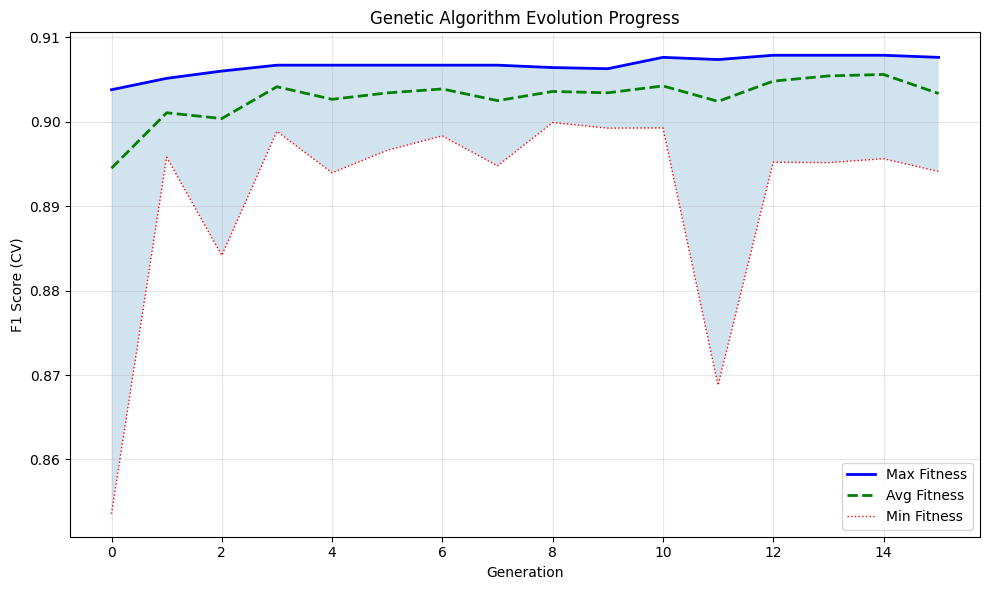

In [49]:
# Plot evolution progress
gen = logbook.select("gen")
fit_max = logbook.select("max")
fit_avg = logbook.select("avg")
fit_min = logbook.select("min")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(gen, fit_max, 'b-', label='Max Fitness', linewidth=2)
ax.plot(gen, fit_avg, 'g--', label='Avg Fitness', linewidth=2)
ax.plot(gen, fit_min, 'r:', label='Min Fitness', linewidth=1)
ax.fill_between(gen, fit_min, fit_max, alpha=0.2)
ax.set_xlabel('Generation')
ax.set_ylabel('F1 Score (CV)')
ax.set_title('Genetic Algorithm Evolution Progress')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# Comparison: All Optimization Methods including GA
print("\n" + "=" * 70)
print("COMPREHENSIVE COMPARISON: ALL OPTIMIZATION METHODS")
print("=" * 70)

comparison_all_optimization = pd.DataFrame({
    'Method': ['Baseline (Default)', 'GridSearch', 'Optuna', 'Genetic Algorithm'],
    'Accuracy': [acc_kbest, acc_gs_kbest, acc_optuna_kbest, acc_ga],
    'F1 Score': [f1_kbest, f1_gs_kbest, f1_optuna_kbest, f1_ga],
    'Precision': [
        precision_score(y_test, y_pred_kbest, average='weighted'),
        precision_gs_kbest, 
        precision_optuna_kbest, 
        precision_ga
    ],
    'Recall': [
        recall_score(y_test, y_pred_kbest, average='weighted'),
        recall_gs_kbest, 
        recall_optuna_kbest, 
        recall_ga
    ]
})
print(comparison_all_optimization.to_string(index=False))

# Find best method
best_method_idx = comparison_all_optimization['F1 Score'].idxmax()
best_method_name = comparison_all_optimization.loc[best_method_idx, 'Method']
best_f1_score = comparison_all_optimization.loc[best_method_idx, 'F1 Score']

print(f"\n{'='*70}")
print(f"BEST OPTIMIZATION METHOD: {best_method_name}")
print(f"Best F1 Score: {best_f1_score:.4f}")
print(f"{'='*70}")


COMPREHENSIVE COMPARISON: ALL OPTIMIZATION METHODS
            Method  Accuracy  F1 Score  Precision   Recall
Baseline (Default)  0.893023  0.891548   0.892843 0.893023
        GridSearch  0.895349  0.894400   0.894743 0.895349
            Optuna  0.886047  0.884131   0.886121 0.886047
 Genetic Algorithm  0.895349  0.893589   0.895791 0.895349

BEST OPTIMIZATION METHOD: GridSearch
Best F1 Score: 0.8944


# Auto-ML: AutoGluon

In [10]:
from autogluon.tabular import TabularPredictor
import warnings

warnings.filterwarnings('ignore')


In [11]:
print("=" * 70)
print("AUTO-ML: AUTOGLUON OPTIMIZATION")
print("=" * 70)
print("AutoGluon will automatically train and compare multiple ML models")
print("This includes: various classifiers, ensembles, and stacking\n")

# Prepare data for AutoGluon (needs DataFrame with target column)
train_data_automl = X_train_kbest.copy()
train_data_automl['target'] = y_train

test_data_automl = X_test_kbest.copy()
test_data_automl['target'] = y_test  # For evaluation

# Train AutoGluon predictor
print("Training AutoGluon models...")
print("This may take several minutes...\n")

predictor = TabularPredictor(
    label='target',
    eval_metric='f1_weighted',
    verbosity=2,
    path='autogluon_models'
).fit(
    train_data=train_data_automl,
    time_limit=180,  # 3 minutes max
    presets='medium_quality_faster_train'
)

print("\nAutoGluon training complete!")


Preset alias specified: 'medium_quality_faster_train' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)


AUTO-ML: AUTOGLUON OPTIMIZATION
AutoGluon will automatically train and compare multiple ML models
This includes: various classifiers, ensembles, and stacking

Training AutoGluon models...
This may take several minutes...



=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.0
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Pytorch Version:    2.2.1+cu118
CUDA Version:       11.8
GPU Memory:         GPU 0: 4.00/4.00 GB
Total GPU Memory:   Free: 4.00 GB, Allocated: 0.00 GB, Total: 4.00 GB
GPU Count:          1
Memory Avail:       3.94 GB / 15.37 GB (25.6%)
Disk Space Avail:   83.98 GB / 476.00 GB (17.6%)
Presets specified: ['medium_quality_faster_train']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 180s
AutoGluon will save models to "c:\Users\Acer\Desktop\advanced-machine-learning\autogluon_models"
Train Data Rows:    1504
Train Data Columns: 15
Label Column:       target
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [0, 1]
	If 'binary' is not the correct probl


AutoGluon training complete!


In [15]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print("\n" + "=" * 70)
print("AUTOGLUON AUTO-ML RESULTS")
print("=" * 70)

# Get leaderboard of all trained models
leaderboard = predictor.leaderboard(test_data_automl, silent=True)
print("\nModel Leaderboard:")
print(leaderboard.to_string())

# Get best model name
best_model_name = predictor.model_best
print(f"\nBest Model: {best_model_name}")

# Make predictions on test set
test_data_no_label = X_test_kbest.copy()
y_pred_automl = predictor.predict(test_data_no_label)
acc_automl = accuracy_score(y_test, y_pred_automl)
f1_automl = f1_score(y_test, y_pred_automl, average='weighted')
precision_automl = precision_score(y_test, y_pred_automl, average='weighted')
recall_automl = recall_score(y_test, y_pred_automl, average='weighted')

print(f"\nTest Set Results (AutoGluon Auto-ML):")
print(f"Accuracy: {acc_automl:.4f}")
print(f"F1 Score: {f1_automl:.4f}")
print(f"Precision: {precision_automl:.4f}")
print(f"Recall: {recall_automl:.4f}")


AUTOGLUON AUTO-ML RESULTS

Model Leaderboard:
                  model  score_test  score_val  eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0              CatBoost    0.888631   0.892672  f1_weighted        0.014539       0.009615   1.233009                 0.014539                0.009615           1.233009            1       True          5
1              LightGBM    0.886833   0.899380  f1_weighted        0.002526       0.007258   1.118308                 0.002526                0.007258           1.118308            1       True          2
2   WeightedEnsemble_L2    0.886833   0.899380  f1_weighted        0.005524       0.009690   1.382998                 0.002998                0.002432           0.264691            2       True         11
3               XGBoost    0.877160   0.892672  f1_weighted        0.016044       0.020120   1.332434                 0.016044       

In [16]:
# Show AutoGluon model comparison results
print("\n" + "=" * 70)
print("AUTOGLUON MODEL COMPARISON SUMMARY")
print("=" * 70)

# Get feature importance
print("\nFeature Importance (from best model):")
try:
    importance = predictor.feature_importance(test_data_automl)
    print(importance.to_string())
except:
    print("Feature importance not available for this model type")

# Model fit summary
print("\n" + "-" * 70)
print("Fit Summary:")
print(predictor.fit_summary())

print("\nAutoGluon models saved to: autogluon_models/")

Computing feature importance via permutation shuffling for 15 features using 430 rows with 5 shuffle sets...
	0.97s	= Expected runtime (0.19s per shuffle set)



AUTOGLUON MODEL COMPARISON SUMMARY

Feature Importance (from best model):


	0.3s	= Actual runtime (Completed 5 of 5 shuffle sets)


                          importance    stddev   p_value  n  p99_high   p99_low
ADL                         0.134955  0.013915  0.000013  5  0.163605  0.106304
FunctionalAssessment        0.122860  0.014301  0.000022  5  0.152306  0.093414
MMSE                        0.102518  0.008171  0.000005  5  0.119342  0.085693
MemoryComplaints            0.080814  0.012242  0.000061  5  0.106020  0.055608
BehavioralProblems          0.077216  0.007241  0.000009  5  0.092125  0.062307
CholesterolTriglycerides    0.003865  0.002164  0.008112  5  0.008322 -0.000591
SleepQuality                0.001528  0.002116  0.090835  5  0.005885 -0.002829
CholesterolHDL              0.000359  0.002803  0.394287  5  0.006131 -0.005413
EducationLevel              0.000000  0.000000  0.500000  5  0.000000  0.000000
HeadInjury                  0.000000  0.000000  0.500000  5  0.000000  0.000000
Ethnicity_Asian             0.000000  0.000000  0.500000  5  0.000000  0.000000
Confusion                  -0.000450  0.

# Final Comprehensive Comparison

Comparing all optimization methods:
1. **Baseline** - CatBoost with default parameters
2. **GridSearch** - Exhaustive hyperparameter search with CV
3. **Optuna** - Bayesian optimization with TPE sampler
4. **Genetic Algorithm** - Evolutionary hyperparameter optimization
5. **AutoGluon Auto-ML** - Automated model comparison and selection

In [51]:
print("=" * 70)
print("FINAL COMPREHENSIVE COMPARISON - ALL METHODS")
print("=" * 70)

final_comparison = pd.DataFrame({
    'Method': ['Baseline (CatBoost Default)', 'GridSearch (CatBoost)', 'Optuna (CatBoost)', 
               'Genetic Algorithm (CatBoost)', 'AutoGluon Auto-ML'],
    'Accuracy': [acc_kbest, acc_gs_kbest, acc_optuna_kbest, acc_ga, acc_automl],
    'F1 Score': [f1_kbest, f1_gs_kbest, f1_optuna_kbest, f1_ga, f1_automl],
    'Precision': [
        precision_score(y_test, y_pred_kbest, average='weighted'),
        precision_gs_kbest,
        precision_optuna_kbest,
        precision_ga,
        precision_automl
    ],
    'Recall': [
        recall_score(y_test, y_pred_kbest, average='weighted'),
        recall_gs_kbest,
        recall_optuna_kbest,
        recall_ga,
        recall_automl
    ]
})

print("\nResults on SelectKBest Features (pycaret_mean_zscore dataset):")
print("-" * 70)
print(final_comparison.to_string(index=False))

# Calculate improvements
baseline_f1 = f1_kbest
print("\n" + "=" * 70)
print("IMPROVEMENT OVER BASELINE")
print("=" * 70)
for idx, row in final_comparison.iterrows():
    if row['Method'] != 'Baseline (CatBoost Default)':
        improvement = ((row['F1 Score'] - baseline_f1) / baseline_f1) * 100
        print(f"{row['Method']}: {improvement:+.2f}% F1 improvement")

# Find best overall method
best_idx = final_comparison['F1 Score'].idxmax()
best_method = final_comparison.loc[best_idx]

print("\n" + "=" * 70)
print("BEST OVERALL METHOD")
print("=" * 70)
print(f"Method: {best_method['Method']}")
print(f"Accuracy: {best_method['Accuracy']:.4f}")
print(f"F1 Score: {best_method['F1 Score']:.4f}")
print(f"Precision: {best_method['Precision']:.4f}")
print(f"Recall: {best_method['Recall']:.4f}")

FINAL COMPREHENSIVE COMPARISON - ALL METHODS

Results on SelectKBest Features (pycaret_mean_zscore dataset):
----------------------------------------------------------------------
                      Method  Accuracy  F1 Score  Precision   Recall
 Baseline (CatBoost Default)  0.893023  0.891548   0.892843 0.893023
       GridSearch (CatBoost)  0.895349  0.894400   0.894743 0.895349
           Optuna (CatBoost)  0.886047  0.884131   0.886121 0.886047
Genetic Algorithm (CatBoost)  0.895349  0.893589   0.895791 0.895349
           AutoGluon Auto-ML  0.888372  0.886833   0.888045 0.888372

IMPROVEMENT OVER BASELINE
GridSearch (CatBoost): +0.32% F1 improvement
Optuna (CatBoost): -0.83% F1 improvement
Genetic Algorithm (CatBoost): +0.23% F1 improvement
AutoGluon Auto-ML: -0.53% F1 improvement

BEST OVERALL METHOD
Method: GridSearch (CatBoost)
Accuracy: 0.8953
F1 Score: 0.8944
Precision: 0.8947
Recall: 0.8953


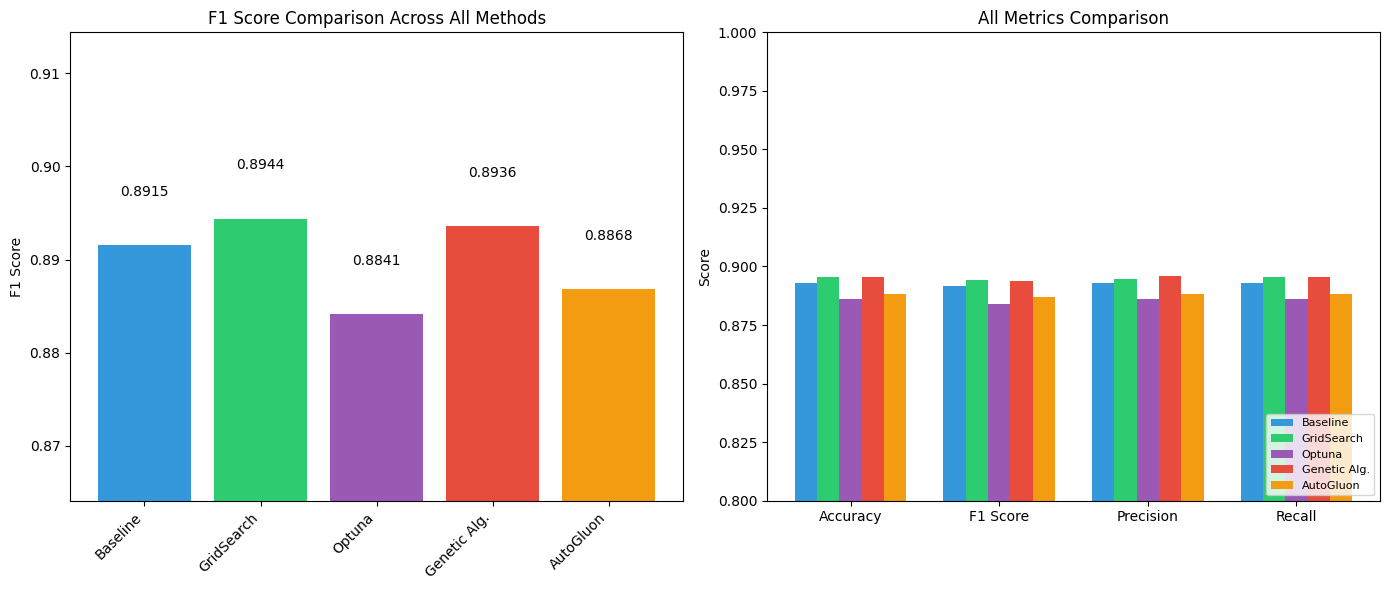

In [52]:
# Visualization of comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart - F1 Scores
methods = final_comparison['Method'].str.replace(' (CatBoost)', '').str.replace(' (CatBoost Default)', '')
f1_scores = final_comparison['F1 Score']
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']

ax1 = axes[0]
bars = ax1.bar(range(len(methods)), f1_scores, color=colors)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(['Baseline', 'GridSearch', 'Optuna', 'Genetic Alg.', 'AutoGluon'], rotation=45, ha='right')
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 Score Comparison Across All Methods')
ax1.set_ylim([min(f1_scores) - 0.02, max(f1_scores) + 0.02])

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{score:.4f}', ha='center', va='bottom', fontsize=10)

# Radar chart for all metrics
ax2 = axes[1]
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
method_names = ['Baseline', 'GridSearch', 'Optuna', 'Genetic Alg.', 'AutoGluon']

x = np.arange(len(metrics))
width = 0.15

for i, (method, color) in enumerate(zip(method_names, colors)):
    values = final_comparison.iloc[i][metrics].values
    ax2.bar(x + i*width, values, width, label=method, color=color)

ax2.set_ylabel('Score')
ax2.set_title('All Metrics Comparison')
ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(metrics)
ax2.legend(loc='lower right', fontsize=8)
ax2.set_ylim([0.8, 1.0])

plt.tight_layout()
plt.show()